# Model LP

Model LP is introduced in chapter 5 of {cite:t}`GodleyLavoie2006MonetaryEconomicsIntegrated` "Monetary Economics: An Integrated Approach to Credit, Money, Income, Production and Wealth". It extends model [PCEX](GL06PCEX.ipynb) by introducing long-term bonds, capital gains, and liquidity preference into the portfolio choice framework. Households now allocate their wealth across three assets: cash, Treasury bills, and long-term bonds.

## Module Contents

As with all `MacroStat` models, LP is divided into Variables, Parameters (fixed constants), Scenarios, and the Behavior (model initialization and steps). The module-level documentation can be seen in:

```{eval-rst}
.. toctree::
    :maxdepth: 2

    Variables <GL06LP/variables.rst>
    Parameters <GL06LP/parameters.rst>
    Equations <GL06LP/equations.rst>
    Scenarios <GL06LP/scenarios.rst>
```

The remainder of this page gives an introduction to the model, notes on how it is implemented in `MacroStat` and then shows some of the model dynamics by replicating the relevant graphs of Godley and Lavoie (2006).

## Model Overview

### Behavioral Equations

Model LP extends model [PCEX](GL06PCEX.ipynb) by adding long-term bonds to the household portfolio. The key innovations are:

- **Long-term bonds** ($BL$) that pay a fixed coupon of 1 monetary unit per period
- **Bond prices** ($p_{bl}$) that are set exogenously and can generate **capital gains** ($CG$)
- **Three-asset portfolio choice** across cash, bills, and bonds using Tobin's framework
- **Expected returns on bonds** that combine yield and expected capital gains

1. National Income
```{math}
:label: gl06_lp_eq501_nationalIncome
Y(t) = C(t) + G(t)
```
2. Disposable income now includes bond coupon income
```{math}
:label: gl06_lp_eq502_disposableIncome
YD_r(t) = Y(t) - T(t) + r_b(t-1) \cdot B_h(t-1) + BL_h(t-1)
```
3. Taxes now include bond income in the tax base
```{math}
:label: gl06_lp_eq503_taxes
T(t) = \theta \cdot \left(Y(t) + r_b(t-1) \cdot B_h(t-1) + BL_h(t-1)\right)
```
4. Wealth now includes capital gains from bond price changes
```{math}
:label: gl06_lp_eq504_wealth
V(t) = V(t-1) + (YD_r(t) - C(t)) + CG(t)
```
5. Capital gains arise from bond price changes
```{math}
:label: gl06_lp_eq505_capitalGains
CG(t) = (p_{bl}(t) - p_{bl}(t-1)) \cdot BL_h(t-1)
```
6. Consumption (unchanged from PCEX)
```{math}
:label: gl06_lp_eq506_consumption
C(t) = \alpha_1 \cdot YD_r^e(t) + \alpha_2 \cdot V(t-1)
```
7. Expected wealth now includes capital gains
```{math}
:label: gl06_lp_eq507_expectedWealth
V^e(t) = V(t-1) + (YD_r^e(t) - C(t)) + CG(t)
```
8. Bond yield is the inverse of the bond price
```{math}
:label: gl06_lp_eq508_bondYield
r_{bl}(t) = \frac{1}{p_{bl}(t)}
```
9. Expected return on bonds combines yield and expected capital gain
```{math}
:label: gl06_lp_eq509_expectedReturnOnBonds
ERr_{bl}(t) = r_{bl}(t) + \chi \cdot \frac{p_{bl}^e(t) - p_{bl}(t)}{p_{bl}(t)}
```
10. In the base LP model, the expected bond price equals the current bond price (static expectations)
```{math}
:label: gl06_lp_eq510_expectedBondPrice
p_{bl}^e(t) = p_{bl}(t)
```
11. Household demand for Treasury bills (Tobin portfolio allocation)
```{math}
:label: gl06_lp_eq511_billDemand
B_d(t) = V^e(t) \cdot \lambda_{20} + V^e(t) \cdot (\lambda_{22} \cdot r_b(t) + \lambda_{23} \cdot ERr_{bl}(t)) + \lambda_{24} \cdot YD_r^e(t)
```
12. Household demand for bonds
```{math}
:label: gl06_lp_eq512_bondDemand
BL_d(t) = \frac{V^e(t) \cdot \left(\lambda_{30} + \lambda_{32} \cdot r_b(t) + \lambda_{33} \cdot ERr_{bl}(t) + \lambda_{34} \cdot \frac{YD_r^e(t)}{V^e(t)}\right)}{p_{bl}(t)}
```
13. Cash demand is the portfolio residual
```{math}
:label: gl06_lp_eq513_cashDemand
H_d(t) = V^e(t) - B_d(t) - p_{bl}(t) \cdot BL_d(t)
```
14. Portfolio holdings equal demands
```{math}
:label: gl06_lp_eq514_portfolioHoldings
B_h(t) = B_d(t) \qquad BL_h(t) = BL_d(t)
```
15. Realized household cash holdings
```{math}
:label: gl06_lp_eq515_householdCash
H_h(t) = V(t) - B_h(t) - p_{bl}(t) \cdot BL_h(t)
```
16. Government budget constraint now includes bond issuance
```{math}
:label: gl06_lp_eq516_governmentBills
:nowrap:

\begin{align}
B_s(t) &= B_s(t-1) + G(t) + r_b(t-1) \cdot B_s(t-1) + BL_s(t-1) \\
&\quad - T(t) - r_b(t-1) \cdot B_{CB}(t-1) - (BL_s(t) - BL_s(t-1)) \cdot p_{bl}(t)
\end{align}
```
17. Central bank bill holdings and money supply
```{math}
:label: gl06_lp_eq517_centralBank
:nowrap:

\begin{align}
B_{CB}(t) &= B_s(t) - B_h(t) \\
H_s(t) &= H_s(t-1) + (B_{CB}(t) - B_{CB}(t-1))
\end{align}
```
18. Expected disposable income (adaptive expectations)
```{math}
:label: gl06_lp_eq518_expectedDisposableIncome
YD_r^e(t) = YD_r(t-1)
```

With the redundant equation being
```{math}
:label: gl06_lp_eq519_redundant
H_s(t) = H_h(t)
```

:::{note}
In Model LP, the expected bond price $p_{bl}^e = p_{bl}$ (static expectations), so the expected capital gain term in $ERr_{bl}$ is always zero, and $ERr_{bl} = r_{bl} = 1/p_{bl}$. Models LP2 and LP3 introduce adaptive expectations where $p_{bl}^e \neq p_{bl}$.
:::

### Transaction Flow Matrix

```{csv-table} Accounting Transaction Matrix for Model LP
:file: GL06LP/transaction_matrix.csv
:header-rows: 2
:stub-columns: 1
```

### Balance Sheet Matrix

```{csv-table} Balance Sheet for Model LP
:file: GL06LP/balance_sheet.csv
:header-rows: 2
:stub-columns: 1
```

## Implementation in MacroStat

Transposing these equations to the `MacroStat` framework, we consider that there are:

1. **Twelve parameters** (fixed constants): $\alpha_1$, $\alpha_2$, $\theta$, $\chi$, and the eight $\lambda$ portfolio coefficients (see [Parameters](GL06LP/parameters.rst))
2. **Three scenario variables**: $G(t)$, $r_b(t)$, and $p_{bl}(t)$ (see [Scenarios](GL06LP/scenarios.rst))
3. The remaining tracked series are variables (see [Variables](GL06LP/variables.rst))

## Model Dynamics

### Preparatory Steps

In [1]:
%load_ext autoreload
%autoreload 2

import importlib
import logging
import sys

# Import the necessary libraries for plotting
from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter

# Import the MacroStat model components
from macrostat.models.GL06LP import GL06LP, ParametersGL06LP, ScenariosGL06LP

# Custom matplotlib style for the documentation
plt.style.use("../../macrostat.mplstyle")
# We show the logging output in the notebook
importlib.reload(logging)
logging.basicConfig(stream=sys.stdout, level=logging.INFO)

### Running the Simulation

First, we can run the model without any shocks to see the convergence to the steady state.

In [2]:
params = ParametersGL06LP()
model = GL06LP(parameters=params)
model.simulate()
output = model.variables.to_pandas()

We can check that the variables are healthy, meaning the redundant equation $H_h = H_s$ holds and all stocks are positive.

:::{Note}
Due to floating point precision, the redundant equation will not hold exactly. We check that the absolute percentage error is below a tolerance.
:::

In [3]:
model.variables.check_health(tolerance=1e-3)

True

An overview of the first 10 steps of the model:

In [4]:
df = model.variables.to_pandas()
df.head(10).T

,time,0,1,2,3,4,5,6,7,8,9
ConsumptionHousehold,Household,0.0,0.0,0.000000,16.124001,29.123171,40.013660,49.124569,56.747089,63.124352,68.459801
ConsumptionGovernment,Government,0.0,0.0,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
NationalIncome,Macroeconomy,0.0,0.0,20.000000,36.124001,49.123169,60.013660,69.124573,76.747086,83.124352,88.459801
Taxes,Household,0.0,0.0,3.876000,7.000832,9.618765,11.808908,13.641264,15.174274,16.456844,17.529890
InterestOnBillsHousehold,Household,0.0,0.0,0.000000,0.000000,0.191050,0.345075,0.474114,0.582067,0.672385,0.747948
BondCouponIncomeHousehold,Household,0.0,0.0,0.000000,0.000000,0.318207,0.574746,0.789669,0.969473,1.119904,1.245759
CentralBankProfits,CentralBank,0.0,0.0,0.000000,0.483720,0.491721,0.510488,0.525822,0.538661,0.549403,0.558390
CapitalGains,Household,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ExpectedCapitalGains,Household,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Wealth,Household,0.0,0.0,16.124001,29.123169,40.013657,49.124569,56.747089,63.124355,68.459801,72.923622


### Convergence to the Steady State

In the steady state of Model LP (with constant bond prices), capital gains are zero, and the model behaves similarly to PCEX but with three-asset portfolio choice. The household allocates its wealth across cash, Treasury bills, and bonds according to the Tobin portfolio equations.

Unlike earlier models, an analytical closed-form steady state is not straightforward for Model LP due to the additional portfolio equations and the interaction between bond yields and portfolio allocation. We therefore rely on the numerical convergence of the simulation.

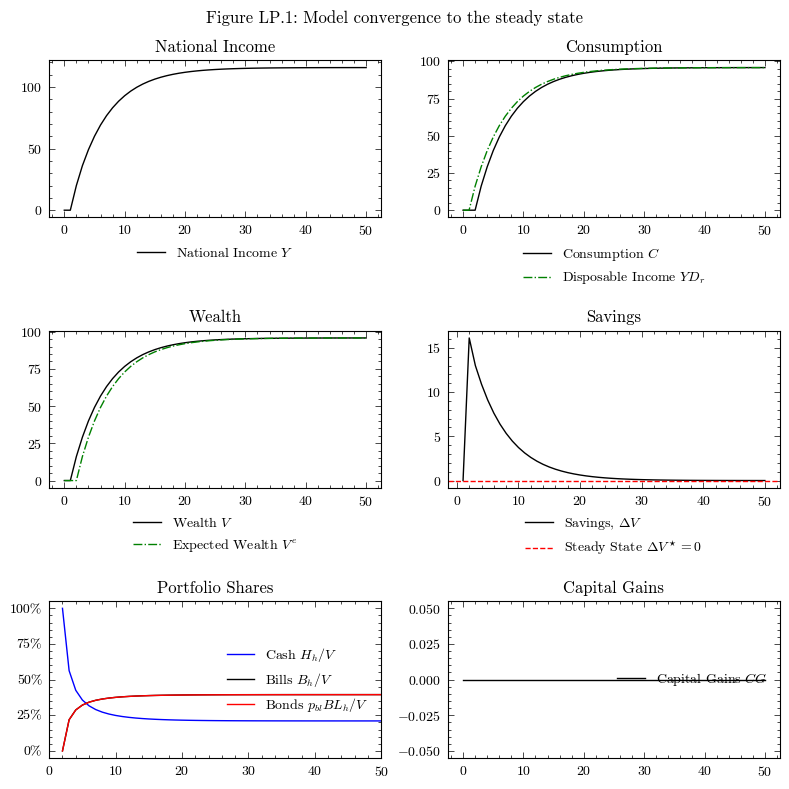

In [5]:
dfo = output.loc[:50]

fig, axs = plt.subplots(ncols=2, nrows=3, figsize=(8, 8))

# National Income
axs[0, 0].plot(dfo.index, dfo['NationalIncome'], color='k', label=r'National Income $Y$')
axs[0, 0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), frameon=False)
axs[0, 0].set_title('National Income')

# Consumption and Disposable Income
axs[0, 1].plot(dfo.index, dfo['ConsumptionHousehold'], color='k', label=r'Consumption $C$')
axs[0, 1].plot(dfo.index, dfo['DisposableIncome'], color='g', linestyle='-.', label=r'Disposable Income $YD_r$')
axs[0, 1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), frameon=False)
axs[0, 1].set_title('Consumption')

# Wealth
axs[1, 0].plot(dfo.index, dfo['Wealth'], color='k', label=r'Wealth $V$')
axs[1, 0].plot(dfo.index, dfo['ExpectedWealth'], color='g', linestyle='-.', label=r'Expected Wealth $V^e$')
axs[1, 0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), frameon=False)
axs[1, 0].set_title('Wealth')

# Savings
axs[1, 1].plot(dfo.index, dfo['Wealth'].diff(), color='k', label=r'Savings, $\Delta V$')
axs[1, 1].axhline(y=0, color='r', linestyle='--', label=r'Steady State $\Delta V^\star=0$')
axs[1, 1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), frameon=False)
axs[1, 1].set_title('Savings')

# Portfolio Shares
cash_share = output['HouseholdCashStock'] / output['Wealth']
bill_share = output['HouseholdBillStock'] / output['Wealth']
bond_share = (output['HouseholdBondStock'].mul(output[('BondPrice','Macroeconomy')],axis=0)) / output['Wealth']

axs[2, 0].plot(output.index, cash_share, color='b', label='Cash $H_h/V$')
axs[2, 0].plot(output.index, bill_share, color='k', label='Bills $B_h/V$')
axs[2, 0].plot(output.index, bond_share, color='r', label='Bonds $p_{bl} BL_h/V$')
axs[2, 0].legend(loc='center right', frameon=False)
axs[2, 0].set_xlim(0, 50)
axs[2, 0].set_title('Portfolio Shares')
axs[2, 0].yaxis.set_major_formatter(PercentFormatter(1))

# Capital Gains
axs[2, 1].plot(dfo.index, dfo['CapitalGains'], color='k', label=r'Capital Gains $CG$')
axs[2, 1].set_title('Capital Gains')
axs[2, 1].legend(loc='center right', frameon=False)

fig.suptitle('Figure LP.1: Model convergence to the steady state')
plt.tight_layout()
plt.show()

### Perturbation 1: Increase in both short-term and long-term interest rates (Section 5.7)

Following Section 5.7 of {cite:t}`GodleyLavoie2006MonetaryEconomicsIntegrated`, we suppose there is an unexpected increase in the interest rates set by the monetary authorities. The bill rate rises from 3% to 4%, while the bond price drops from 20 to 15 (the bond yield rises from 5% to 6.67%). With static expectations ($p_{bl}^e = p_{bl}$), the expected return on bonds rises by the same amount as the yield.

The most important point of this experiment is that the fall in bond prices induces an **immediate reduction in wealth** through capital losses. This is one of the main conduits for monetary policy — a rise in interest rates reduces demand temporarily through the wealth channel in the consumption function. However, in the **long run**, the effect of higher interest rates is positive because higher debt service payments increase household income.

In [6]:
scenarios = ScenariosGL06LP(parameters=params)
sc1 = scenarios.get_scenario_index("Scenario.1: Rise in interest rates")
model1 = GL06LP(parameters=params, scenarios=scenarios)
model1.simulate(scenario=sc1)
output_sc1 = model1.variables.to_pandas()

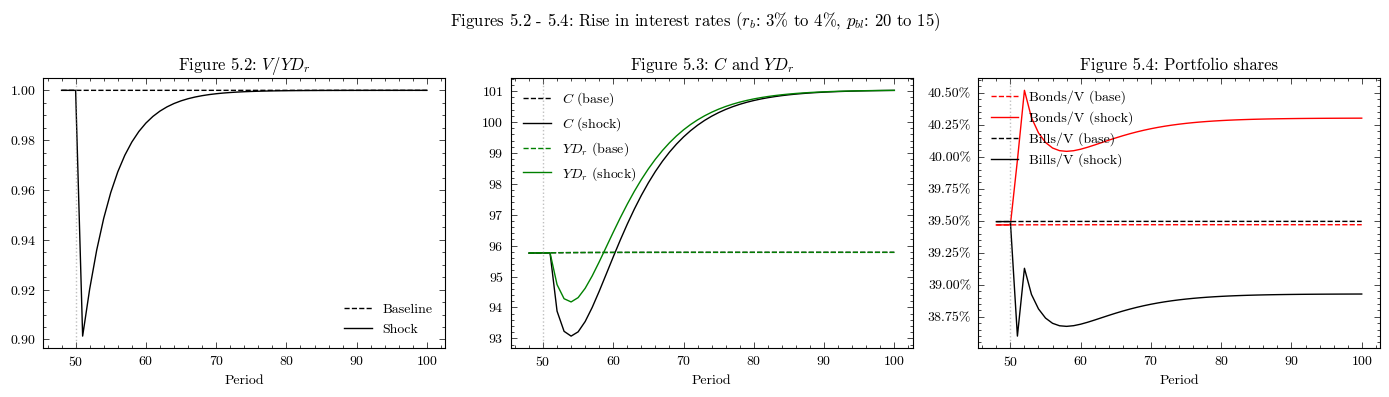

In [7]:
trigger = params["scenario_trigger"]
dfo = output_sc1.loc[trigger - 2:]
dfo_base = output.loc[trigger - 2:]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Figure 5.2: V/YDr ratio
v_yd_base = dfo_base['Wealth'] / dfo_base['DisposableIncome']
v_yd_shock = dfo['Wealth'] / dfo['DisposableIncome']
axes[0].plot(dfo_base.index, v_yd_base, 'k--', label='Baseline')
axes[0].plot(dfo.index, v_yd_shock, 'k-', label='Shock')
axes[0].axvline(x=trigger, color='grey', linestyle=':', alpha=0.5)
axes[0].set_title('Figure 5.2: $V / YD_r$')
axes[0].set_xlabel('Period')
axes[0].legend(frameon=False)

# Figure 5.3: C and YDr
axes[1].plot(dfo_base.index, dfo_base['ConsumptionHousehold'], 'k--', label='$C$ (base)')
axes[1].plot(dfo.index, dfo['ConsumptionHousehold'], 'k-', label='$C$ (shock)')
axes[1].plot(dfo_base.index, dfo_base['DisposableIncome'], 'g--', label='$YD_r$ (base)')
axes[1].plot(dfo.index, dfo['DisposableIncome'], 'g-', label='$YD_r$ (shock)')
axes[1].axvline(x=trigger, color='grey', linestyle=':', alpha=0.5)
axes[1].set_title('Figure 5.3: $C$ and $YD_r$')
axes[1].set_xlabel('Period')
axes[1].legend(frameon=False)

# Figure 5.4: portfolio shares
bond_share_sc1 = output_sc1['HouseholdBondStock'].mul(output_sc1[('BondPrice',"Macroeconomy")],axis=0).div(output_sc1['Wealth'])
bill_share_sc1 = output_sc1['HouseholdBillStock'] / output_sc1['Wealth']
bond_share_base = output['HouseholdBondStock'].mul(output[('BondPrice',"Macroeconomy")],axis=0).div(output['Wealth'])
bill_share_base = output['HouseholdBillStock'] / output['Wealth']

axes[2].plot(bond_share_base.loc[trigger - 2:].index, bond_share_base.loc[trigger - 2:], 'r--', label='Bonds/V (base)')
axes[2].plot(bond_share_sc1.loc[trigger - 2:].index, bond_share_sc1.loc[trigger - 2:], 'r-', label='Bonds/V (shock)')
axes[2].plot(bill_share_base.loc[trigger - 2:].index, bill_share_base.loc[trigger - 2:], 'k--', label='Bills/V (base)')
axes[2].plot(bill_share_sc1.loc[trigger - 2:].index, bill_share_sc1.loc[trigger - 2:], 'k-', label='Bills/V (shock)')
axes[2].axvline(x=trigger, color='grey', linestyle=':', alpha=0.5)
axes[2].set_title('Figure 5.4: Portfolio shares')
axes[2].set_xlabel('Period')
axes[2].yaxis.set_major_formatter(PercentFormatter(1))
axes[2].legend(frameon=False)

fig.suptitle('Figures 5.2 - 5.4: Rise in interest rates ($r_b$: 3% to 4%, $p_{bl}$: 20 to 15)')
plt.tight_layout()
plt.show()

### Perturbation 2: Sharp decrease in propensity to consume (Section 5.9, LP baseline)

Following Section 5.9 of {cite:t}`GodleyLavoie2006MonetaryEconomicsIntegrated`, we reduce the propensity to consume out of current income ($\alpha_1$) by 0.1. This has a negative short-run impact on GDP, but in Model LP (with exogenous government spending), the economy eventually recovers *above* the initial steady state. The larger saving leads to more government debt, higher interest payments, and hence higher disposable income in the long run.

This result serves as the crucial comparison with Model LP3 (Figure 5.10 vs Figure 5.11), where the fiscal austerity rule prevents the recovery.

In [8]:
scenarios = ScenariosGL06LP(parameters=params)
sc2 = scenarios.get_scenario_index("Scenario.2: Drop in alpha1")
model2 = GL06LP(parameters=params, scenarios=scenarios)
model2.simulate(scenario=sc2)
output_sc2 = model2.variables.to_pandas()

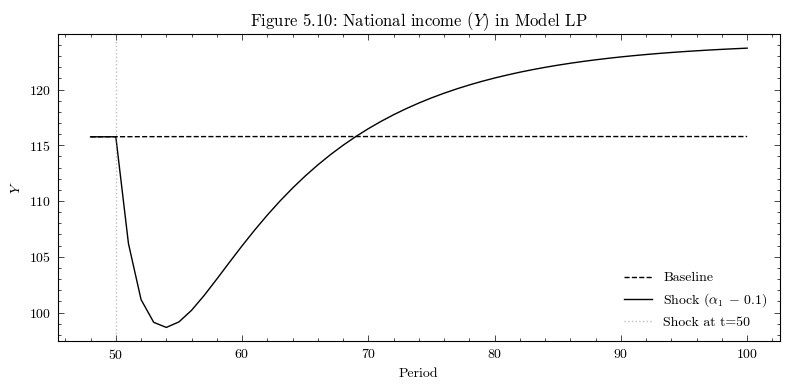

In [9]:
dfo = output_sc2.loc[trigger - 2:]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(dfo_base.index, dfo_base['NationalIncome'], 'k--', label='Baseline')
ax.plot(dfo.index, dfo['NationalIncome'], 'k-', label='Shock ($\\alpha_1$ − 0.1)')
ax.axvline(x=trigger, color='grey', linestyle=':', alpha=0.5, label=f'Shock at t={trigger}')
ax.set_title('Figure 5.10: National income ($Y$) in Model LP')
ax.set_xlabel('Period')
ax.set_ylabel('$Y$')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()